# 🧮 Linear Regression from Scratch — CS229 Style

## Stanford CS229: Machine Learning (Lecture 2)

In this notebook, we implement linear regression **from scratch** using only NumPy.

We will implement:
1. Feature Normalization
2. Cost Function $J(\theta)$
3. Batch Gradient Descent
4. Stochastic Gradient Descent (SGD)
5. Normal Equation (Closed-form solution)
6. Predictions & Visualization

### Problem: House Price Prediction
Given features like **size**, **number of bedrooms**, and **age**, predict the **price** of a house.

### Mathematical Foundation

**Hypothesis:**
$$h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

**Cost Function:**
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

**Gradient Descent Update:**
$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

**Normal Equation:**
$$\theta = (X^T X)^{-1} X^T \vec{y}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# For nice plots inside the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
from matplotlib import rcParams

rcParams["font.family"] = "DejaVu Sans"

## 1. Create the Dataset

We'll create a small dataset of house features and prices.

| Feature | Description |
|---------|-------------|
| $x_1$ | Size (square feet) |
| $x_2$ | Number of bedrooms |
| $x_3$ | Age of house (years) |
| $y$ | Price (thousands of dollars) |

In [3]:
# Features: [size (sq ft), bedrooms, age (years)]
X_raw = np.array([
    [2104, 3, 20],
    [1416, 2, 15],
    [1534, 3, 10],
    [852,  2, 35],
    [1940, 4, 5],
    [1755, 3, 12],
    [1268, 2, 25],
    [1900, 4, 8],
    [1022, 2, 30],
    [1736, 3, 18],
    [1635, 3, 22],
    [1594, 2, 14]
])

# Target: house prices (in thousands of dollars)
y = np.array([460, 232, 315, 178, 420, 390, 270, 410, 195, 380, 350, 310])

m = len(y)            # number of training examples
n = X_raw.shape[1]    # number of features

# Display as a nice table
df = pd.DataFrame(X_raw, columns=['Size (sqft)', 'Bedrooms', 'Age (years)'])
df['Price ($k)'] = y
print(f"Dataset: {m} examples, {n} features\n")
df

Dataset: 12 examples, 3 features



,Size (sqft),Bedrooms,Age (years),Price ($k)
0,2104,3,20,460
1,1416,2,15,232
2,1534,3,10,315
3,852,2,35,178
4,1940,4,5,420
5,1755,3,12,390
6,1268,2,25,270
7,1900,4,8,410
8,1022,2,30,195
9,1736,3,18,380


## 2. Visualize the Data

Before building any model, **always look at your data first.**

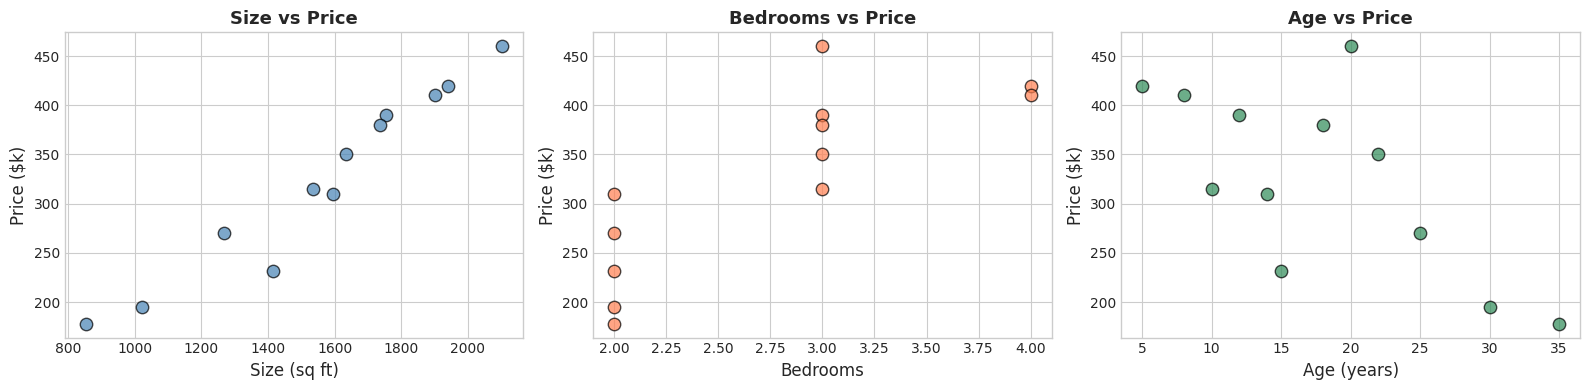

📊 Observations:
• Larger houses → higher prices
• More bedrooms → higher prices
• Older houses → lower prices


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Size vs Price
axes[0].scatter(X_raw[:, 0], y, color='steelblue', s=80, edgecolors='k', alpha=0.7)
axes[0].set_xlabel('Size (sq ft)', fontsize=12)
axes[0].set_ylabel('Price ($k)', fontsize=12)
axes[0].set_title('Size vs Price', fontsize=13, fontweight='bold')

# Plot 2: Bedrooms vs Price
axes[1].scatter(X_raw[:, 1], y, color='coral', s=80, edgecolors='k', alpha=0.7)
axes[1].set_xlabel('Bedrooms', fontsize=12)
axes[1].set_ylabel('Price ($k)', fontsize=12)
axes[1].set_title('Bedrooms vs Price', fontsize=13, fontweight='bold')

# Plot 3: Age vs Price
axes[2].scatter(X_raw[:, 2], y, color='seagreen', s=80, edgecolors='k', alpha=0.7)
axes[2].set_xlabel('Age (years)', fontsize=12)
axes[2].set_ylabel('Price ($k)', fontsize=12)
axes[2].set_title('Age vs Price', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Observations:")
print("• Larger houses → higher prices")
print("• More bedrooms → higher prices")
print("• Older houses → lower prices")

## 3. Feature Normalization

**Why is this important?**

Our features have very different scales:
- Size: ~800 to ~2100
- Bedrooms: ~2 to ~4
- Age: ~5 to ~35

Without normalization, gradient descent will oscillate and converge **very slowly**
because the cost function will be elongated (like a narrow valley).

**Formula:**
$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation of feature $j$.

In [5]:
def feature_normalize(X):
    """
    Normalize features to have mean=0 and std=1
    
    Parameters:
        X: (m, n) matrix of features
    
    Returns:
        X_norm: normalized features
        mu: mean of each feature (needed for predictions later)
        sigma: std of each feature (needed for predictions later)
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalize
X_norm, mu, sigma = feature_normalize(X_raw)

# Add intercept term (column of 1s)
X = np.c_[np.ones(m), X_norm]    # Shape: (m, n+1)

print("Feature Statistics:")
print(f"  Mean (μ):  {mu}")
print(f"  Std (σ):   {sigma}")
print(f"\nX shape after adding intercept: {X.shape}")
print(f"\nFirst 3 rows of X (normalized with intercept):")

df_norm = pd.DataFrame(X, columns=['x₀ (intercept)', 'x₁ (size)', 'x₂ (beds)', 'x₃ (age)'])
df_norm.head(3)

Feature Statistics:
  Mean (μ):  [1563.            2.75         17.83333333]
  Std (σ):   [356.95401198   0.72168784   8.63938012]

X shape after adding intercept: (12, 4)

First 3 rows of X (normalized with intercept):


,x₀ (intercept),x₁ (size),x₂ (beds),x₃ (age)
0,1.0,1.515601,0.34641,0.250790
1,1.0,-0.411818,-1.03923,-0.327956
2,1.0,-0.081243,0.34641,-0.906701


## 4. Core Functions

### 4.1 Hypothesis Function
$$h_\theta(x) = \theta^T x = X\theta$$

### 4.2 Cost Function
$$J(\theta) = \frac{1}{2m} (X\theta - \vec{y})^T (X\theta - \vec{y})$$

In [6]:
def hypothesis(X, theta):
    """
    Compute predictions for all examples
    
    h_θ(x) = X @ θ
    
    Parameters:
        X: (m, n+1) design matrix
        theta: (n+1,) parameter vector
    
    Returns:
        predictions: (m,) vector
    """
    return X @ theta


def compute_cost(X, y, theta):
    """
    Compute the cost function J(θ)
    
    J(θ) = (1/2m) Σ(h_θ(x⁽ⁱ⁾) - y⁽ⁱ⁾)²
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector
        theta: (n+1,) parameter vector
    
    Returns:
        cost: scalar value of J(θ)
    """
    m = len(y)
    errors = hypothesis(X, theta) - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


# Test with initial theta = zeros
initial_theta = np.zeros(n + 1)
initial_cost = compute_cost(X, y, initial_theta)
print(f"Initial theta: {initial_theta}")
print(f"Initial cost J(θ=0): {initial_cost:.2f}")
print(f"\nThis is high because our predictions are all 0, but actual prices are ~$200k-$460k")

Initial theta: [0. 0. 0. 0.]
Initial cost J(θ=0): 56952.42

This is high because our predictions are all 0, but actual prices are ~$200k-$460k


## 5. Batch Gradient Descent

Update **all parameters simultaneously** using **all** training examples:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

**Vectorized form:**
$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - \vec{y})$$

In [7]:
def batch_gradient_descent(X, y, theta, alpha, num_iterations):
    """
    Perform batch gradient descent to learn theta.
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector
        theta: (n+1,) initial parameters
        alpha: learning rate
        num_iterations: number of iterations
    
    Returns:
        theta: optimized parameters
        cost_history: list of cost at each iteration
        theta_history: list of theta at each iteration
    """
    m = len(y)
    cost_history = []
    theta_history = []
    
    for i in range(num_iterations):
        # Step 1: Compute predictions
        predictions = hypothesis(X, theta)
        
        # Step 2: Compute errors
        errors = predictions - y
        
        # Step 3: Compute gradient (vectorized)
        gradient = (1/m) * (X.T @ errors)
        
        # Step 4: Update parameters
        theta = theta - alpha * gradient
        
        # Track history
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        theta_history.append(theta.copy())
    
    return theta, cost_history, theta_history


# Train!
print("Training with Batch Gradient Descent...")
print(f"Learning rate α = 0.1")
print(f"Iterations = 500\n")

theta_bgd, cost_history_bgd, _ = batch_gradient_descent(
    X, y, 
    theta=np.zeros(n + 1),
    alpha=0.1, 
    num_iterations=500
)

print(f"Optimized θ: {np.round(theta_bgd, 2)}")
print(f"  θ₀ (intercept): {theta_bgd[0]:.2f}")
print(f"  θ₁ (size):      {theta_bgd[1]:.2f}")
print(f"  θ₂ (bedrooms):  {theta_bgd[2]:.2f}")
print(f"  θ₃ (age):       {theta_bgd[3]:.2f}")
print(f"\nFinal cost: {cost_history_bgd[-1]:.4f}")

Training with Batch Gradient Descent...
Learning rate α = 0.1
Iterations = 500

Optimized θ: [325.83  84.37  20.8   19.66]
  θ₀ (intercept): 325.83
  θ₁ (size):      84.37
  θ₂ (bedrooms):  20.80
  θ₃ (age):       19.66

Final cost: 99.0802


## 6. Stochastic Gradient Descent (SGD)

Instead of using **all** examples per update, use **one random example** at a time:

$$\text{For each example } i: \quad \theta_j := \theta_j - \alpha \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

**Pros:** Faster per iteration, can escape local minima  
**Cons:** Noisy convergence, oscillates around the minimum

In [8]:
def stochastic_gradient_descent(X, y, theta, alpha, num_epochs):
    """
    Perform stochastic gradient descent.
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector
        theta: (n+1,) initial parameters
        alpha: learning rate
        num_epochs: number of passes through the entire dataset
    
    Returns:
        theta: optimized parameters
        cost_history: list of cost after each epoch
    """
    m = len(y)
    cost_history = []
    
    for epoch in range(num_epochs):
        # Shuffle data each epoch
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(m):
            # Pick one example
            xi = X_shuffled[i:i+1]    # Shape: (1, n+1)
            yi = y_shuffled[i:i+1]    # Shape: (1,)
            
            # Compute gradient for this single example
            error = hypothesis(xi, theta) - yi
            gradient = (xi.T @ error).flatten()
            
            # Update
            theta = theta - alpha * gradient
        
        # Track cost after each full pass
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
    
    return theta, cost_history


# Train!
print("Training with Stochastic Gradient Descent...")
print(f"Learning rate α = 0.01")
print(f"Epochs = 100\n")

theta_sgd, cost_history_sgd = stochastic_gradient_descent(
    X, y,
    theta=np.zeros(n + 1),
    alpha=0.01,
    num_epochs=100
)

print(f"Optimized θ: {np.round(theta_sgd, 2)}")
print(f"Final cost: {cost_history_sgd[-1]:.4f}")

Training with Stochastic Gradient Descent...
Learning rate α = 0.01
Epochs = 100

Optimized θ: [325.75  80.38  22.39  17.24]
Final cost: 101.7103


## 7. Normal Equation (Closed-Form Solution)

Solve for θ **directly** without any iteration:

$$\theta = (X^T X)^{-1} X^T \vec{y}$$

This is derived by setting the gradient of $J(\theta)$ to zero and solving algebraically.

In [9]:
def normal_equation(X, y):
    """
    Compute the optimal θ using the normal equation.
    
    θ = (X^T X)^(-1) X^T y
    
    Parameters:
        X: (m, n+1) design matrix
        y: (m,) target vector
    
    Returns:
        theta: (n+1,) optimal parameters
    """
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta


# Solve!
print("Solving with Normal Equation...\n")

theta_ne = normal_equation(X, y)

print(f"Optimal θ: {np.round(theta_ne, 2)}")
print(f"  θ₀ (intercept): {theta_ne[0]:.2f}")
print(f"  θ₁ (size):      {theta_ne[1]:.2f}")
print(f"  θ₂ (bedrooms):  {theta_ne[2]:.2f}")
print(f"  θ₃ (age):       {theta_ne[3]:.2f}")
print(f"\nCost: {compute_cost(X, y, theta_ne):.4f}")
print(f"\n💡 No iterations needed! No learning rate needed!")

Solving with Normal Equation...

Optimal θ: [325.83  84.37  20.8   19.66]
  θ₀ (intercept): 325.83
  θ₁ (size):      84.37
  θ₂ (bedrooms):  20.80
  θ₃ (age):       19.66

Cost: 99.0802

💡 No iterations needed! No learning rate needed!


## 8. Convergence Visualization

Let's see how the cost function $J(\theta)$ decreased during training.

- **Batch GD**: Should show smooth, monotonic decrease
- **SGD**: Should show noisier but faster initial decrease

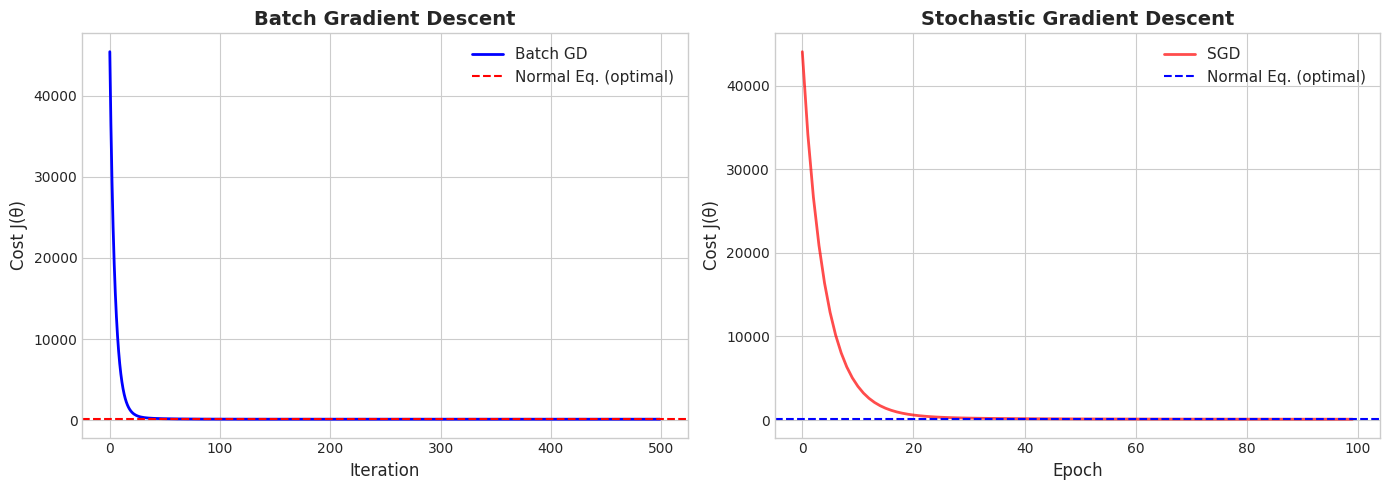

📊 Notice:
• Batch GD shows SMOOTH convergence
• SGD shows NOISY but fast convergence
• Both approach the optimal cost from the Normal Equation


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Batch Gradient Descent
axes[0].plot(cost_history_bgd, 'b-', linewidth=2, label='Batch GD')
axes[0].axhline(y=compute_cost(X, y, theta_ne), color='r', linestyle='--', 
                linewidth=1.5, label='Normal Eq. (optimal)')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost J(θ)', fontsize=12)
axes[0].set_title('Batch Gradient Descent', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Plot 2: Stochastic Gradient Descent
axes[1].plot(cost_history_sgd, 'r-', linewidth=2, alpha=0.7, label='SGD')
axes[1].axhline(y=compute_cost(X, y, theta_ne), color='b', linestyle='--', 
                linewidth=1.5, label='Normal Eq. (optimal)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Cost J(θ)', fontsize=12)
axes[1].set_title('Stochastic Gradient Descent', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("📊 Notice:")
print("• Batch GD shows SMOOTH convergence")
print("• SGD shows NOISY but fast convergence")
print("• Both approach the optimal cost from the Normal Equation")

## 9. Effect of Learning Rate

The learning rate $\alpha$ is **crucial**. Let's see what happens with different values:
- **Too small** → Very slow convergence
- **Just right** → Fast, smooth convergence  
- **Too large** → Diverges! Cost function explodes

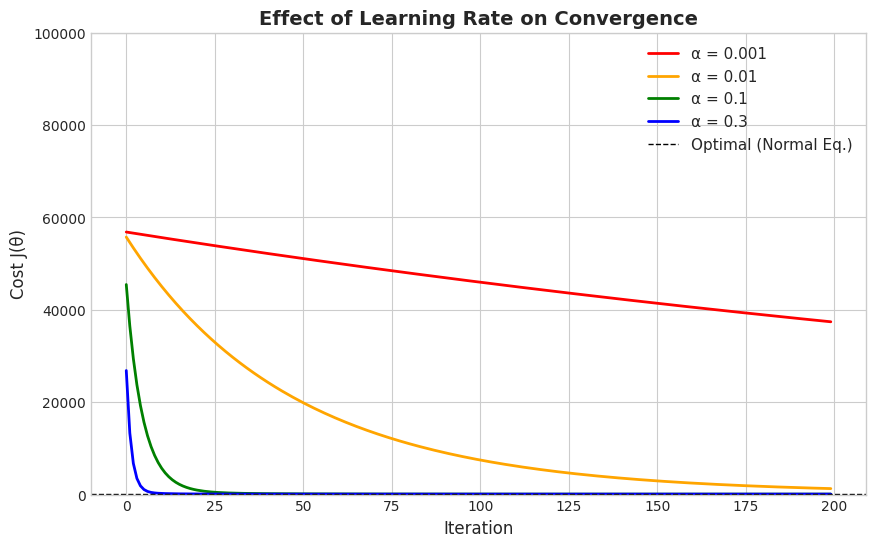

📊 Key Insight:
• α = 0.001: Too slow, barely moves
• α = 0.01:  Converges but slowly
• α = 0.1:   Good convergence speed
• α = 0.3:   Fast but might oscillate
• α > 1.0:   Would DIVERGE (cost explodes to infinity)


In [11]:
alphas = [0.001, 0.01, 0.1, 0.3]
colors = ['red', 'orange', 'green', 'blue']

plt.figure(figsize=(10, 6))

for alpha, color in zip(alphas, colors):
    _, cost_hist, _ = batch_gradient_descent(
        X, y, np.zeros(n + 1), alpha=alpha, num_iterations=200
    )
    plt.plot(cost_hist, color=color, linewidth=2, label=f'α = {alpha}')

plt.axhline(y=compute_cost(X, y, theta_ne), color='black', linestyle='--', 
            linewidth=1, label='Optimal (Normal Eq.)')

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(θ)', fontsize=12)
plt.title('Effect of Learning Rate on Convergence', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0, max(cost_history_bgd[0] * 1.1, 100000))
plt.show()

print("📊 Key Insight:")
print("• α = 0.001: Too slow, barely moves")
print("• α = 0.01:  Converges but slowly")
print("• α = 0.1:   Good convergence speed")
print("• α = 0.3:   Fast but might oscillate")
print("• α > 1.0:   Would DIVERGE (cost explodes to infinity)")

## 10. Make Predictions

Now let's use our trained models to predict house prices!

**Important:** We must normalize new inputs using the **same** $\mu$ and $\sigma$ from training.

In [12]:
def predict(features, theta, mu, sigma):
    """
    Predict the price for a new house.
    
    Parameters:
        features: raw feature values (NOT normalized)
        theta: trained parameters
        mu: mean from training normalization
        sigma: std from training normalization
    
    Returns:
        predicted price
    """
    # Normalize using training statistics
    features_norm = (features - mu) / sigma
    # Add intercept
    x = np.concatenate([[1], features_norm])
    # Predict
    return x @ theta


# Test houses
test_houses = np.array([
    [1650, 3, 10],   # Medium house, fairly new
    [2400, 4, 5],    # Large new house
    [900,  2, 40],   # Small old house
    [1800, 3, 15],   # Medium house
])

test_labels = [
    "Medium house, 10 years old",
    "Large new house, 5 years old",
    "Small old house, 40 years old",
    "Medium house, 15 years old"
]

print("=" * 65)
print("HOUSE PRICE PREDICTIONS")
print("=" * 65)
print(f"{'Description':<35} {'BGD':>8} {'SGD':>8} {'Normal':>8}")
print("-" * 65)

for house, label in zip(test_houses, test_labels):
    p_bgd = predict(house, theta_bgd, mu, sigma)
    p_sgd = predict(house, theta_sgd, mu, sigma)
    p_ne  = predict(house, theta_ne, mu, sigma)
    print(f"{label:<35} ${p_bgd:>6.1f}k  ${p_sgd:>6.1f}k  ${p_ne:>6.1f}k")

print("-" * 65)
print("\n💡 All three methods give very similar predictions!")

HOUSE PRICE PREDICTIONS
Description                              BGD      SGD   Normal
-----------------------------------------------------------------
Medium house, 10 years old          $ 335.8k  $ 337.5k  $ 335.8k
Large new house, 5 years old        $ 530.5k  $ 527.4k  $ 530.5k
Small old house, 40 years old       $ 197.9k  $ 197.4k  $ 197.9k
Medium house, 15 years old          $ 382.6k  $ 381.2k  $ 382.6k
-----------------------------------------------------------------

💡 All three methods give very similar predictions!


## 11. Model Evaluation: Actual vs Predicted

A good model should have predictions close to the diagonal line (perfect predictions).

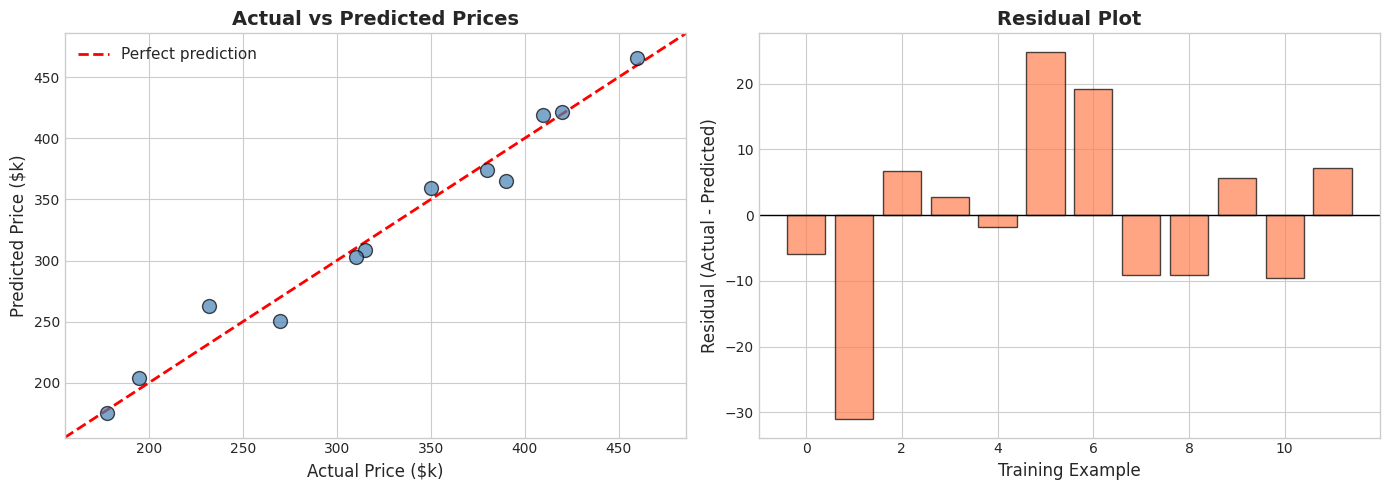

📊 Model Performance:
  Mean Absolute Error: $11.06k
  Root Mean Square Error: $14.08k
  R² Score: 0.9744

  R² = 1.0 means perfect fit
  R² = 0.0 means no better than predicting the mean


In [13]:
predictions_ne = hypothesis(X, theta_ne)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y, predictions_ne, color='steelblue', s=100, edgecolors='k', alpha=0.7, zorder=5)
min_val = min(y.min(), predictions_ne.min()) - 20
max_val = max(y.max(), predictions_ne.max()) + 20
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($k)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($k)', fontsize=12)
axes[0].set_title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)

# Plot 2: Residuals
residuals = y - predictions_ne
axes[1].bar(range(m), residuals, color='coral', edgecolor='k', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Training Example', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Compute R² score
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"📊 Model Performance:")
print(f"  Mean Absolute Error: ${np.mean(np.abs(residuals)):.2f}k")
print(f"  Root Mean Square Error: ${np.sqrt(np.mean(residuals**2)):.2f}k")
print(f"  R² Score: {r_squared:.4f}")
print(f"\n  R² = 1.0 means perfect fit")
print(f"  R² = 0.0 means no better than predicting the mean")

## 12. Interpreting the Parameters

Our model: $h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3$

Since we **normalized** the features, the magnitude of each $\theta_j$ tells us 
the **relative importance** of each feature.

PARAMETER INTERPRETATION
  Intercept (θ₀)      :   325.83
  Size (θ₁)           :    84.37
  Bedrooms (θ₂)       :    20.80
  Age (θ₃)            :    19.66

📊 Interpretation:
  • Intercept (325.8): Average predicted price
  • Size (84.4): Strongest positive effect
  • Bedrooms (20.8): Moderate positive effect
  • Age (19.7): Negative effect (older = cheaper)


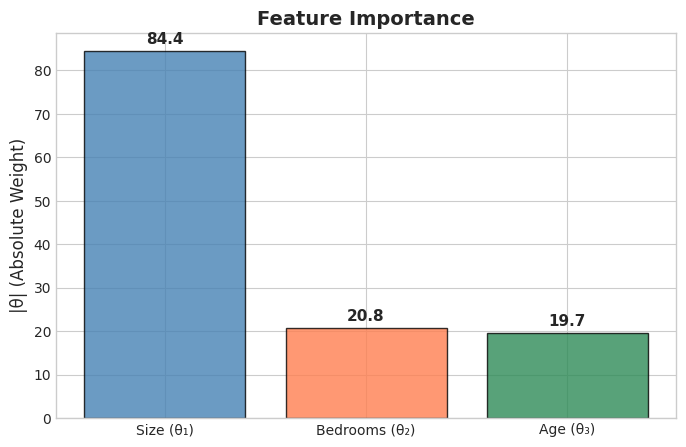

In [14]:
feature_names = ['Intercept (θ₀)', 'Size (θ₁)', 'Bedrooms (θ₂)', 'Age (θ₃)']

print("PARAMETER INTERPRETATION")
print("=" * 50)
for name, val in zip(feature_names, theta_ne):
    print(f"  {name:<20}: {val:>8.2f}")

print(f"\n📊 Interpretation:")
print(f"  • Intercept ({theta_ne[0]:.1f}): Average predicted price")
print(f"  • Size ({theta_ne[1]:.1f}): Strongest positive effect")
print(f"  • Bedrooms ({theta_ne[2]:.1f}): Moderate positive effect") 
print(f"  • Age ({theta_ne[3]:.1f}): Negative effect (older = cheaper)")

# Bar chart of feature importance
plt.figure(figsize=(8, 5))
importance = np.abs(theta_ne[1:])
colors = ['steelblue', 'coral', 'seagreen']
bars = plt.bar(feature_names[1:], importance, color=colors, edgecolor='k', alpha=0.8)
plt.ylabel('|θ| (Absolute Weight)', fontsize=12)
plt.title('Feature Importance', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, theta_ne[1:]):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.show()

## 13. Final Comparison: All Three Methods

Let's put everything together and compare our three approaches.

In [15]:
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

comparison_data = {
    'Method': ['Batch GD', 'Stochastic GD', 'Normal Equation'],
    'θ₀': [theta_bgd[0], theta_sgd[0], theta_ne[0]],
    'θ₁': [theta_bgd[1], theta_sgd[1], theta_ne[1]],
    'θ₂': [theta_bgd[2], theta_sgd[2], theta_ne[2]],
    'θ₃': [theta_bgd[3], theta_sgd[3], theta_ne[3]],
    'Final Cost': [
        cost_history_bgd[-1],
        cost_history_sgd[-1],
        compute_cost(X, y, theta_ne)
    ]
}

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.round(2)
df_compare

FINAL MODEL COMPARISON


,Method,θ₀,θ₁,θ₂,θ₃,Final Cost
0,Batch GD,325.83,84.37,20.80,19.66,99.08
1,Stochastic GD,325.75,80.38,22.39,17.24,101.71
2,Normal Equation,325.83,84.37,20.80,19.66,99.08


## 14. Summary & Key Takeaways

### What We Learned (CS229 Lecture 2):

| Concept | Key Takeaway |
|---------|-------------|
| **Feature Normalization** | Essential for gradient descent to converge properly |
| **Cost Function** | Measures how wrong our predictions are |
| **Batch Gradient Descent** | Smooth convergence, uses all data per step |
| **Stochastic Gradient Descent** | Faster but noisy, uses one example per step |
| **Normal Equation** | Exact solution, no hyperparameters, but $O(n^3)$ |
| **Learning Rate** | Too small = slow, too large = diverge |
| **Feature Importance** | Normalized weights tell us which features matter most |

### When to Use What?

| Scenario | Best Method |
|----------|-------------|
| Small dataset, few features ($n < 10000$) | Normal Equation |
| Large dataset, many features | Batch/Mini-batch GD |
| Very large dataset (millions of examples) | SGD |
| Non-linear models (neural networks, etc.) | Must use GD variants |

### Next Steps (CS229 Lecture 3+):
- **Logistic Regression** for classification
- **Regularization** to prevent overfitting
- **Support Vector Machines** (SVMs)